<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/main/Wk_6_Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (200, 5)

First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
# checking missing values and encoding 'gender' feature into integers
print("\nMissing Values:")
print(df.isnull().sum())

if df['Gender'].dtype == 'object':
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})


Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
### EDA of data here
df.describe()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.560000,38.850000,60.560000,50.200000
std,57.879185,0.497633,13.969007,26.264721,25.823522
min,1.000000,0.000000,18.000000,15.000000,1.000000
25%,50.750000,0.000000,28.750000,41.500000,34.750000
50%,100.500000,1.000000,36.000000,61.500000,50.000000
75%,150.250000,1.000000,49.000000,78.000000,73.000000
max,200.000000,1.000000,70.000000,137.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


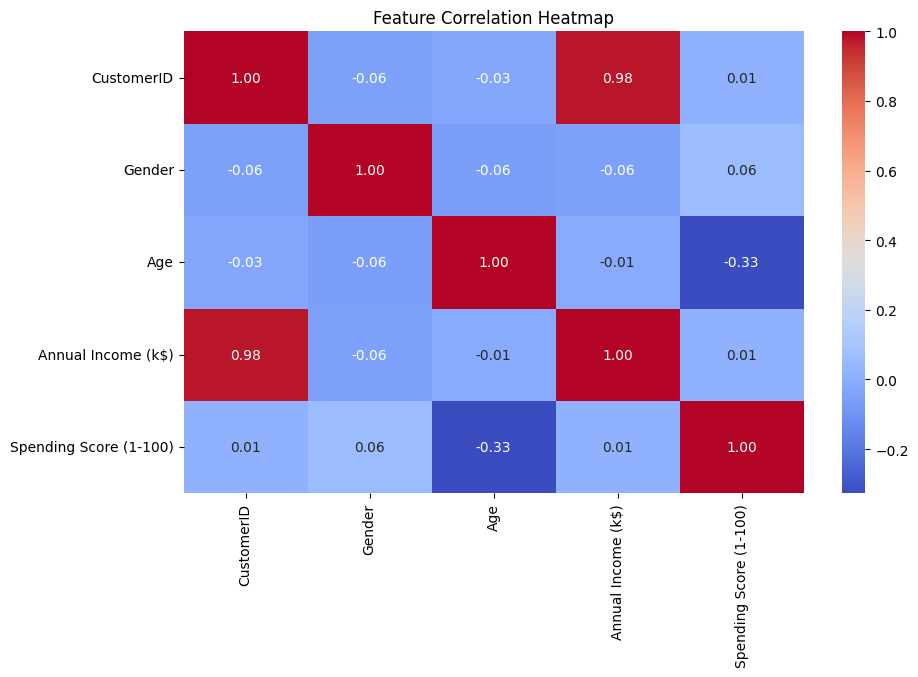

In [ ]:
#correlation between features
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

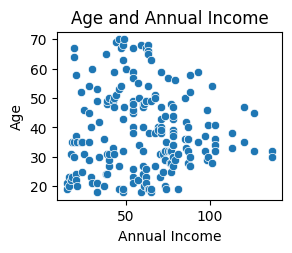

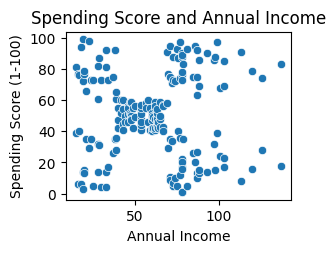

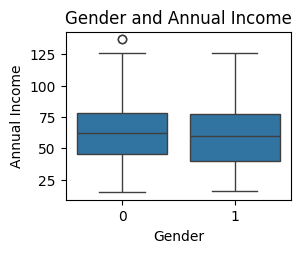

In [ ]:
#how do all features affect annual income? scatter plots
plt.figure(1)

plt.subplot(221)
sns.scatterplot(x= df['Annual Income (k$)'], y=df['Age'])
plt.xlabel('Annual Income')
plt.ylabel('Age')
plt.title('Age and Annual Income')
plt.show()

plt.subplot(222)
sns.scatterplot(x= df['Annual Income (k$)'], y=df['Spending Score (1-100)'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score (1-100)')
plt.title('Spending Score and Annual Income')
plt.show()

plt.subplot(223)
sns.boxplot(x=df['Gender'], y=df['Annual Income (k$)'])
plt.xlabel('Gender')
plt.ylabel('Annual Income')
plt.title('Gender and Annual Income')
plt.show()


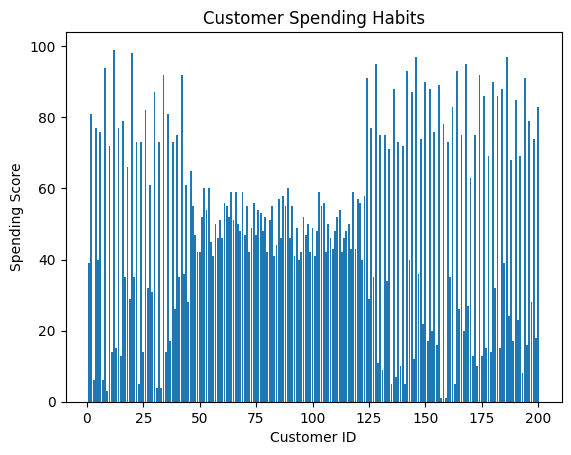

In [ ]:
# customer spending habits?

x = np.array(df['CustomerID'])
y = np.array(df['Spending Score (1-100)'])

plt.xlabel('Customer ID')
plt.ylabel('Spending Score')
plt.title('Customer Spending Habits')


plt.bar(x,y)
plt.show()

In [ ]:
# selelcting features for clustering and scaling them
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

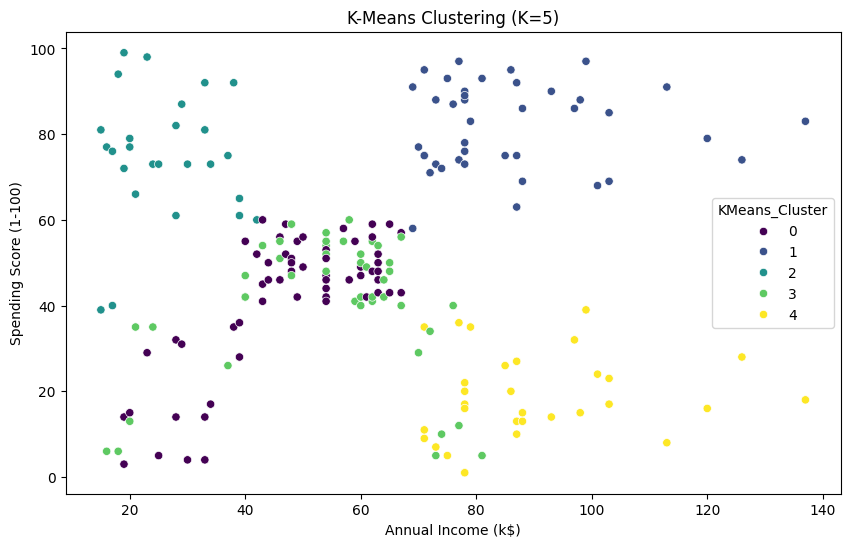

In [ ]:
# K-means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)
df['KMeans_Cluster'] = kmeans.labels_

#plotting k-means graph
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', data=df, palette='viridis')
plt.title('K-Means Clustering (K=5)')
plt.show()

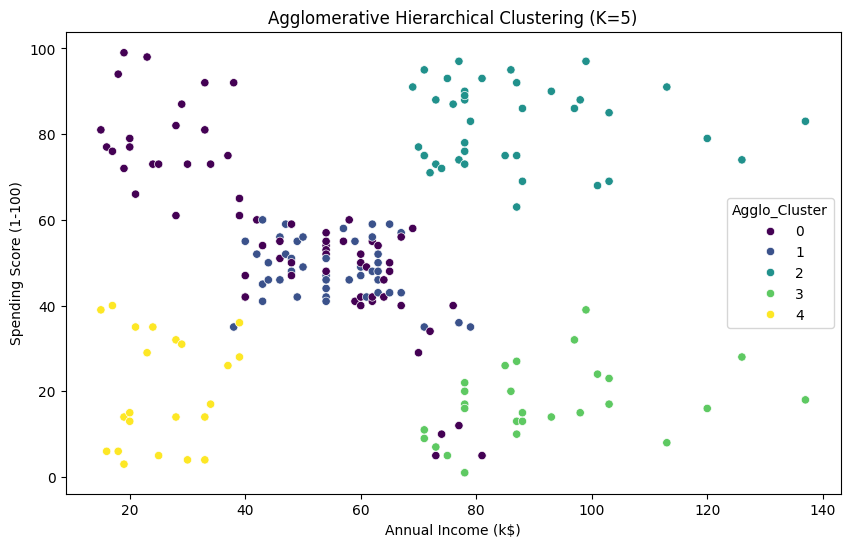

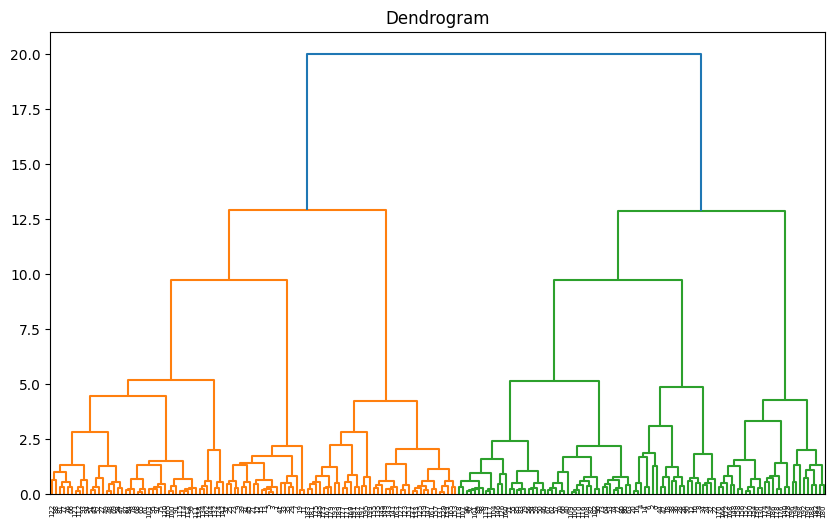

In [ ]:
# Hierarchical Clustering

# Agglomerative Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=5)
df['Agglo_Cluster'] = agglo.fit_predict(X_scaled)

# graph for Hierarchical Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agglo_Cluster', data=df, palette='viridis')
plt.title('Agglomerative Hierarchical Clustering (K=5)')
plt.show()

# Dendrogram for Hierarchical Clustering
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram')
plt.show()

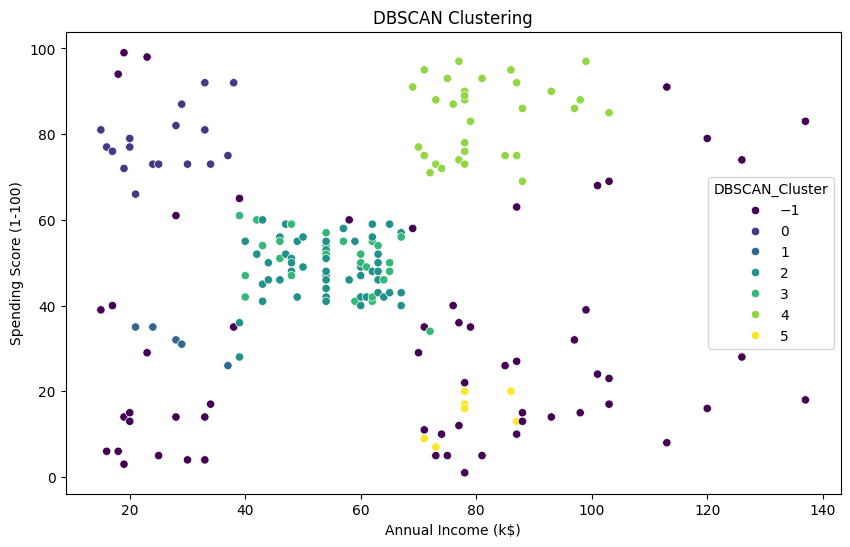

In [ ]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Graph for DBSCAN Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=df, palette='viridis')
plt.title('DBSCAN Clustering')
plt.show()

In [ ]:
# Evaluate Clustering Performance

# silhouette score measures accuracy of clustering groups
# 1= most accurate, 0= insignificant , -1= low accuracy
print("\nK-Means Silhouette Score:", silhouette_score(X_scaled, kmeans.labels_))
print("Agglomerative Silhouette Score:", silhouette_score(X_scaled, agglo.labels_))
print("DBSCAN Silhouette Score:", silhouette_score(X_scaled, dbscan.labels_))

# CH score measures ratio of dispersion outside and inside clusters
# higher score means clusters are denser/well separated
print("\nK-Means Calinski-Harabasz Index:", calinski_harabasz_score(X_scaled, kmeans.labels_))
print("Agglomerative Calinski-Harabasz Index:", calinski_harabasz_score(X_scaled, agglo.labels_))
print("DBSCAN Calinski-Harabasz Index:", calinski_harabasz_score(X_scaled, dbscan.labels_))

# DB score measures similarity between clusters
# 0 or lower indicates better defined cluster
print("\nK-Means Davies-Bouldin Index:", davies_bouldin_score(X_scaled, kmeans.labels_))
print("Agglomerative Davies-Bouldin Index:", davies_bouldin_score(X_scaled, agglo.labels_))
print("DBSCAN Davies-Bouldin Index:", davies_bouldin_score(X_scaled, dbscan.labels_))


K-Means Silhouette Score: 0.40846873777345605
Agglomerative Silhouette Score: 0.39002826186267214
DBSCAN Silhouette Score: 0.18451372756506046

K-Means Calinski-Harabasz Index: 123.41870976849417
Agglomerative Calinski-Harabasz Index: 107.82656032570374
DBSCAN Calinski-Harabasz Index: 34.07053246361936

K-Means Davies-Bouldin Index: 0.8889693268899006
Agglomerative Davies-Bouldin Index: 0.9162886109753661
DBSCAN Davies-Bouldin Index: 1.7569458461701164


/tmp/ipykernel_7586/1328374842.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


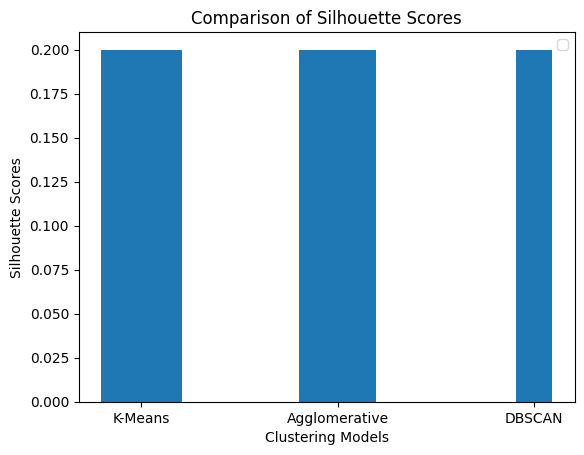

In [ ]:
# comparing scores for each clustering technique

s_scores = silhouette_score(X_scaled, kmeans.labels_), silhouette_score(X_scaled, agglo.labels_), silhouette_score(X_scaled, dbscan.labels_)
x = ["K-Means", "Agglomerative", "DBSCAN"]

positions = np.arange(len(s_scores))
bar_width = 0.2

plt.bar(positions, bar_width, s_scores)

plt.xlabel('Clustering Models')
plt.ylabel('Silhouette Scores')
plt.title('Comparison of Silhouette Scores')

plt.legend()
plt.xticks(positions, ['K-Means', 'Agglomerative', 'DBSCAN'])
plt.show()


/tmp/ipykernel_7586/2159807568.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


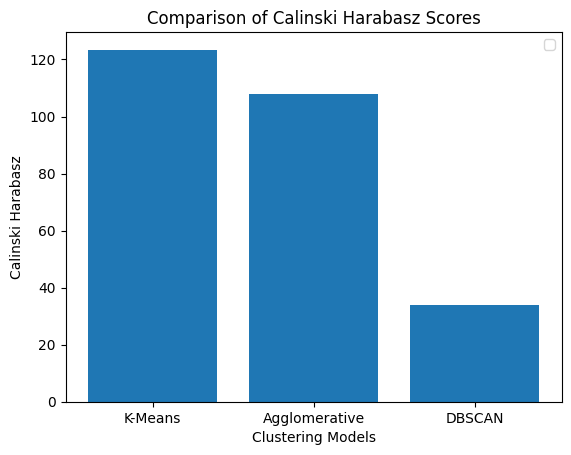

In [ ]:
ch_scores = calinski_harabasz_score(X_scaled, kmeans.labels_), calinski_harabasz_score(X_scaled, agglo.labels_), calinski_harabasz_score(X_scaled, dbscan.labels_)
x = ["K-Means", "Agglomerative", "DBSCAN"]

positions = np.arange(len(ch_scores))


plt.bar(positions, ch_scores)

plt.xlabel('Clustering Models')
plt.ylabel('Calinski Harabasz')
plt.title('Comparison of Calinski Harabasz Scores')

plt.legend()
plt.xticks(positions, ['K-Means', 'Agglomerative', 'DBSCAN'])
plt.show()

/tmp/ipykernel_7586/258501333.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


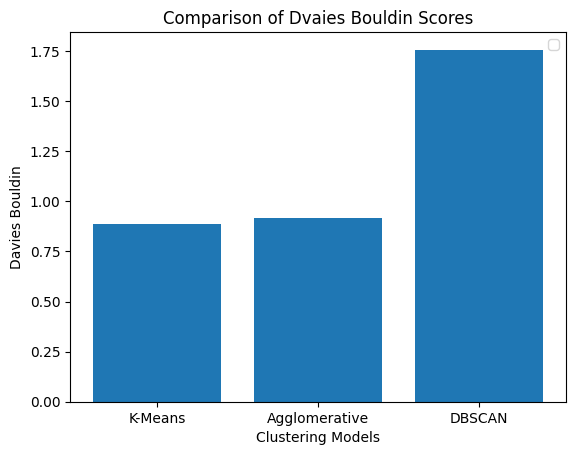

In [ ]:
db_scores = davies_bouldin_score(X_scaled, kmeans.labels_), davies_bouldin_score(X_scaled, agglo.labels_), davies_bouldin_score(X_scaled, dbscan.labels_)
x = ["K-Means", "Agglomerative", "DBSCAN"]

positions = np.arange(len(db_scores))


plt.bar(positions, db_scores)

plt.xlabel('Clustering Models')
plt.ylabel('Davies Bouldin')
plt.title('Comparison of Dvaies Bouldin Scores')

plt.legend()
plt.xticks(positions, ['K-Means', 'Agglomerative', 'DBSCAN'])
plt.show()